In [111]:
import os
from datetime import datetime
import pandas as pd 
import calendar

path = "D:\\other\\Dana\\traffic crashes\\chicago"
os.chdir(path)

In [112]:
dfv = pd.read_csv('Traffic_Crashes_Vehicles_20240409_reduced.csv', low_memory=False)
dfd = pd.read_csv('Traffic_Crashes_People_20240409_reduced.csv', low_memory=False)
dfv = dfv.drop(dfv.columns[:2], axis=1)
dfd = dfd.drop(dfd.columns[:2], axis=1)


In [113]:
unique_values = dfv['CRASH_RECORD_ID'].nunique()
print("Number of unique instances:", unique_values)


Number of unique instances: 821716


In [80]:
dfd.columns

Index(['PERSON_TYPE', 'VEHICLE_ID', 'CRASH_DATE', 'SEAT_NO', 'CITY', 'STATE',
       'ZIPCODE', 'SEX', 'AGE', 'DRIVERS_LICENSE_STATE',
       'DRIVERS_LICENSE_CLASS', 'SAFETY_EQUIPMENT', 'AIRBAG_DEPLOYED',
       'EJECTION', 'INJURY_CLASSIFICATION', 'HOSPITAL', 'EMS_AGENCY',
       'EMS_RUN_NO', 'DRIVER_ACTION', 'DRIVER_VISION', 'PHYSICAL_CONDITION',
       'PEDPEDAL_ACTION', 'PEDPEDAL_VISIBILITY', 'PEDPEDAL_LOCATION',
       'BAC_RESULT', 'BAC_RESULT VALUE', 'CELL_PHONE_USE', 'CRASH_RECORD_ID'],
      dtype='object')

In [126]:
dfd["BAC_RESULT VALUE"].value_counts()

0.00    196
0.18    139
0.17    136
0.21    119
0.14    113
0.20    111
0.16    107
0.19     98
0.15     88
0.22     83
0.23     77
0.12     74
0.13     74
0.11     73
0.24     69
0.26     49
0.25     46
0.27     37
0.10     37
0.09     33
0.28     32
0.08     25
0.29     20
0.30     18
0.07     18
0.03     17
0.33     16
0.04     15
0.05     11
0.32     10
0.35      9
0.02      8
0.31      8
0.06      8
0.38      7
0.36      4
0.34      4
0.39      3
1.00      3
0.44      3
0.01      3
0.79      2
0.88      2
0.45      2
0.60      2
0.95      1
0.40      1
0.47      1
0.99      1
0.41      1
0.80      1
0.58      1
0.37      1
0.85      1
0.67      1
0.98      1
Name: BAC_RESULT VALUE, dtype: int64

In [81]:
dfv.columns

Index(['CRASH_DATE', 'UNIT_NO', 'UNIT_TYPE', 'NUM_PASSENGERS', 'VEHICLE_ID',
       'CMRC_VEH_I', 'MAKE', 'MODEL', 'LIC_PLATE_STATE', 'VEHICLE_YEAR',
       'VEHICLE_DEFECT', 'VEHICLE_TYPE', 'VEHICLE_USE', 'TRAVEL_DIRECTION',
       'MANEUVER', 'TOWED_I', 'FIRE_I', 'OCCUPANT_CNT', 'EXCEED_SPEED_LIMIT_I',
       'TOWED_BY', 'TOWED_TO', 'AREA_00_I', 'AREA_01_I', 'AREA_02_I',
       'AREA_03_I', 'AREA_04_I', 'AREA_05_I', 'AREA_06_I', 'AREA_07_I',
       'AREA_08_I', 'AREA_09_I', 'AREA_10_I', 'AREA_11_I', 'AREA_12_I',
       'AREA_99_I', 'FIRST_CONTACT_POINT', 'CMV_ID', 'USDOT_NO', 'CCMC_NO',
       'ILCC_NO', 'COMMERCIAL_SRC', 'GVWR', 'CARRIER_NAME', 'CARRIER_STATE',
       'CARRIER_CITY', 'HAZMAT_PLACARDS_I', 'HAZMAT_NAME', 'UN_NO',
       'HAZMAT_PRESENT_I', 'HAZMAT_REPORT_I', 'HAZMAT_REPORT_NO',
       'MCS_REPORT_I', 'MCS_REPORT_NO', 'HAZMAT_VIO_CAUSE_CRASH_I',
       'MCS_VIO_CAUSE_CRASH_I', 'IDOT_PERMIT_NO', 'WIDE_LOAD_I',
       'TRAILER1_WIDTH', 'TRAILER2_WIDTH', 'TRAILER1_LENGTH'

In [82]:
dfv[['MAKE', 'MODEL', 'VEHICLE_YEAR','VEHICLE_DEFECT', 'VEHICLE_TYPE','MANEUVER' ]][7000:7010]

,MAKE,MODEL,VEHICLE_YEAR,VEHICLE_DEFECT,VEHICLE_TYPE,MANEUVER
7000,MERCURY,COUGAR,1999.0,UNKNOWN,PASSENGER,STRAIGHT AHEAD
7001,BUICK,REGAL,NaN,NONE,PASSENGER,TURNING LEFT
7002,FORD,EXPEDITION,1998.0,UNKNOWN,PASSENGER,BACKING
7003,CHEVROLET,IMPALA,2009.0,NONE,PASSENGER,STRAIGHT AHEAD
7004,LEXUS,OTHER (EXPLAIN IN NARRATIVE),2008.0,UNKNOWN,PASSENGER,BACKING
7005,MERCEDES-BENZ,OTHER (EXPLAIN IN NARRATIVE),1999.0,UNKNOWN,PASSENGER,PARKED
7006,UNKNOWN,OTHER (EXPLAIN IN NARRATIVE),NaN,UNKNOWN,UNKNOWN/NA,UNKNOWN/NA
7007,JEEP,CHEROKEE,2000.0,UNKNOWN,SPORT UTILITY VEHICLE (SUV),PARKED
7008,UNKNOWN,OTHER (EXPLAIN IN NARRATIVE),NaN,UNKNOWN,UNKNOWN/NA,UNKNOWN/NA
7009,HONDA,FIT,2013.0,UNKNOWN,PASSENGER,PARKED


In [83]:
dfd[['PERSON_TYPE','SEX', 'AGE','DRIVER_ACTION', 'DRIVER_VISION','INJURY_CLASSIFICATION','AIRBAG_DEPLOYED', 'SAFETY_EQUIPMENT']][14000:14020]

,PERSON_TYPE,SEX,AGE,DRIVER_ACTION,DRIVER_VISION,INJURY_CLASSIFICATION,AIRBAG_DEPLOYED,SAFETY_EQUIPMENT
14000,DRIVER,M,47.0,FOLLOWED TOO CLOSELY,NOT OBSCURED,NO INDICATION OF INJURY,DID NOT DEPLOY,SAFETY BELT USED
14001,DRIVER,M,47.0,NONE,NOT OBSCURED,NO INDICATION OF INJURY,DID NOT DEPLOY,SAFETY BELT USED
14002,DRIVER,M,NaN,IMPROPER BACKING,NOT OBSCURED,NO INDICATION OF INJURY,DID NOT DEPLOY,SAFETY BELT USED
14003,DRIVER,M,NaN,NONE,NOT OBSCURED,NO INDICATION OF INJURY,DID NOT DEPLOY,SAFETY BELT USED
14004,DRIVER,M,47.0,FOLLOWED TOO CLOSELY,UNKNOWN,NO INDICATION OF INJURY,DID NOT DEPLOY,USAGE UNKNOWN
14005,DRIVER,F,70.0,UNKNOWN,UNKNOWN,NO INDICATION OF INJURY,NOT APPLICABLE,USAGE UNKNOWN
14006,DRIVER,M,NaN,FAILED TO YIELD,UNKNOWN,NO INDICATION OF INJURY,NOT APPLICABLE,NONE PRESENT
14007,DRIVER,M,NaN,UNKNOWN,UNKNOWN,NO INDICATION OF INJURY,NOT APPLICABLE,NONE PRESENT
14008,DRIVER,M,52.0,UNKNOWN,UNKNOWN,NO INDICATION OF INJURY,DID NOT DEPLOY,USAGE UNKNOWN
14009,DRIVER,M,81.0,IMPROPER TURN,NOT OBSCURED,NO INDICATION OF INJURY,DID NOT DEPLOY,SAFETY BELT USED


In [84]:
dfv.columns

Index(['CRASH_DATE', 'UNIT_NO', 'UNIT_TYPE', 'NUM_PASSENGERS', 'VEHICLE_ID',
       'CMRC_VEH_I', 'MAKE', 'MODEL', 'LIC_PLATE_STATE', 'VEHICLE_YEAR',
       'VEHICLE_DEFECT', 'VEHICLE_TYPE', 'VEHICLE_USE', 'TRAVEL_DIRECTION',
       'MANEUVER', 'TOWED_I', 'FIRE_I', 'OCCUPANT_CNT', 'EXCEED_SPEED_LIMIT_I',
       'TOWED_BY', 'TOWED_TO', 'AREA_00_I', 'AREA_01_I', 'AREA_02_I',
       'AREA_03_I', 'AREA_04_I', 'AREA_05_I', 'AREA_06_I', 'AREA_07_I',
       'AREA_08_I', 'AREA_09_I', 'AREA_10_I', 'AREA_11_I', 'AREA_12_I',
       'AREA_99_I', 'FIRST_CONTACT_POINT', 'CMV_ID', 'USDOT_NO', 'CCMC_NO',
       'ILCC_NO', 'COMMERCIAL_SRC', 'GVWR', 'CARRIER_NAME', 'CARRIER_STATE',
       'CARRIER_CITY', 'HAZMAT_PLACARDS_I', 'HAZMAT_NAME', 'UN_NO',
       'HAZMAT_PRESENT_I', 'HAZMAT_REPORT_I', 'HAZMAT_REPORT_NO',
       'MCS_REPORT_I', 'MCS_REPORT_NO', 'HAZMAT_VIO_CAUSE_CRASH_I',
       'MCS_VIO_CAUSE_CRASH_I', 'IDOT_PERMIT_NO', 'WIDE_LOAD_I',
       'TRAILER1_WIDTH', 'TRAILER2_WIDTH', 'TRAILER1_LENGTH'

In [123]:
dfd["INJURY_CLASSIFICATION"].value_counts()

NO INDICATION OF INJURY     1646271
NONINCAPACITATING INJURY      88264
REPORTED, NOT EVIDENT         50938
INCAPACITATING INJURY         16436
FATAL                           996
Name: INJURY_CLASSIFICATION, dtype: int64

In [116]:
pd.set_option('display.max_columns', None)

In [119]:
dfv["AREA_00_I"].unique()

array([nan, 'Y', 'N'], dtype=object)

In [85]:
dfv['YEAR'] = dfv['CRASH_DATE'].apply(lambda x: x[6:10])

In [86]:
dfd['YEAR'] = dfd['CRASH_DATE'].apply(lambda x: x[6:10])

In [87]:
dfd['MONTH'] = dfd['CRASH_DATE'].apply(lambda x: calendar.month_name[int(x[0:2])])
dfv['MONTH'] = dfv['CRASH_DATE'].apply(lambda x: calendar.month_name[int(x[0:2])])

In [88]:

def get_day_of_week(date_string):
    date_object = datetime.strptime(date_string, '%m/%d/%Y %I:%M:%S %p')
    
    day_of_week = date_object.strftime("%A")
    
    return day_of_week

day_of_week = get_day_of_week(dfv['CRASH_DATE'][0])
print("The day of the week is:", day_of_week)


The day of the week is: Wednesday


In [89]:
dfd['Day of Week'] = dfd['CRASH_DATE'].apply(get_day_of_week)
dfv['Day of Week'] = dfv['CRASH_DATE'].apply(get_day_of_week)

In [90]:
dfv.columns

Index(['CRASH_DATE', 'UNIT_NO', 'UNIT_TYPE', 'NUM_PASSENGERS', 'VEHICLE_ID',
       'CMRC_VEH_I', 'MAKE', 'MODEL', 'LIC_PLATE_STATE', 'VEHICLE_YEAR',
       'VEHICLE_DEFECT', 'VEHICLE_TYPE', 'VEHICLE_USE', 'TRAVEL_DIRECTION',
       'MANEUVER', 'TOWED_I', 'FIRE_I', 'OCCUPANT_CNT', 'EXCEED_SPEED_LIMIT_I',
       'TOWED_BY', 'TOWED_TO', 'AREA_00_I', 'AREA_01_I', 'AREA_02_I',
       'AREA_03_I', 'AREA_04_I', 'AREA_05_I', 'AREA_06_I', 'AREA_07_I',
       'AREA_08_I', 'AREA_09_I', 'AREA_10_I', 'AREA_11_I', 'AREA_12_I',
       'AREA_99_I', 'FIRST_CONTACT_POINT', 'CMV_ID', 'USDOT_NO', 'CCMC_NO',
       'ILCC_NO', 'COMMERCIAL_SRC', 'GVWR', 'CARRIER_NAME', 'CARRIER_STATE',
       'CARRIER_CITY', 'HAZMAT_PLACARDS_I', 'HAZMAT_NAME', 'UN_NO',
       'HAZMAT_PRESENT_I', 'HAZMAT_REPORT_I', 'HAZMAT_REPORT_NO',
       'MCS_REPORT_I', 'MCS_REPORT_NO', 'HAZMAT_VIO_CAUSE_CRASH_I',
       'MCS_VIO_CAUSE_CRASH_I', 'IDOT_PERMIT_NO', 'WIDE_LOAD_I',
       'TRAILER1_WIDTH', 'TRAILER2_WIDTH', 'TRAILER1_LENGTH'

In [91]:
set(dfd["INJURY_CLASSIFICATION"].to_list())

{'FATAL',
 'INCAPACITATING INJURY',
 'NO INDICATION OF INJURY',
 'NONINCAPACITATING INJURY',
 'REPORTED, NOT EVIDENT',
 nan}

In [92]:
set(dfv['YEAR'].to_list()) # 2013 to 2023

{'2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024'}

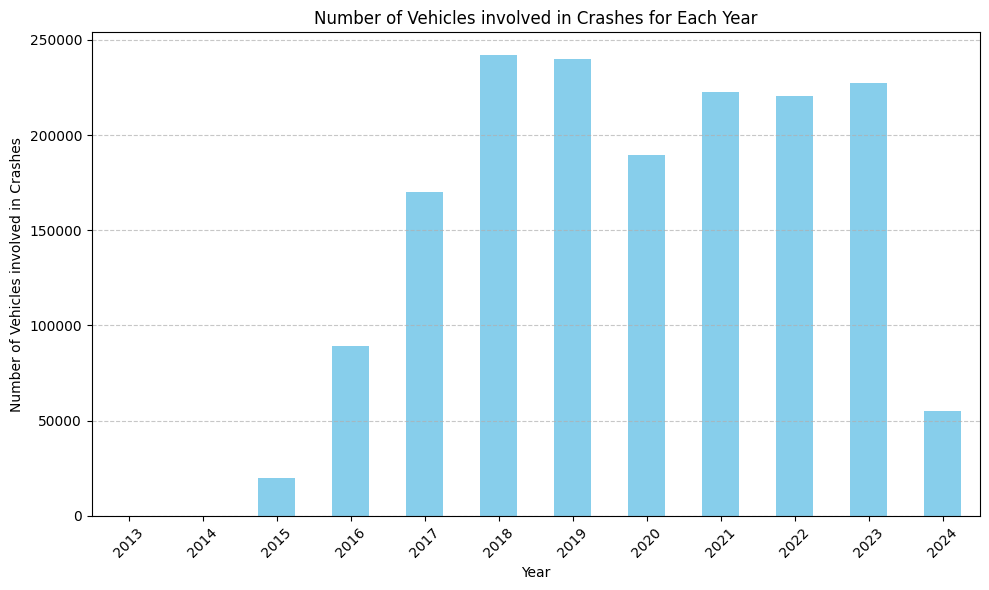

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

year_counts = dfv.groupby('YEAR').size()

plt.figure(figsize=(10, 6))
year_counts.plot(kind='bar', color='skyblue')
plt.title('Number of Vehicles involved in Crashes for Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Vehicles involved in Crashes')
plt.xticks(rotation=45)  
plt.grid(axis='y', linestyle='--', alpha=0.7)  
plt.tight_layout()
plt.show()


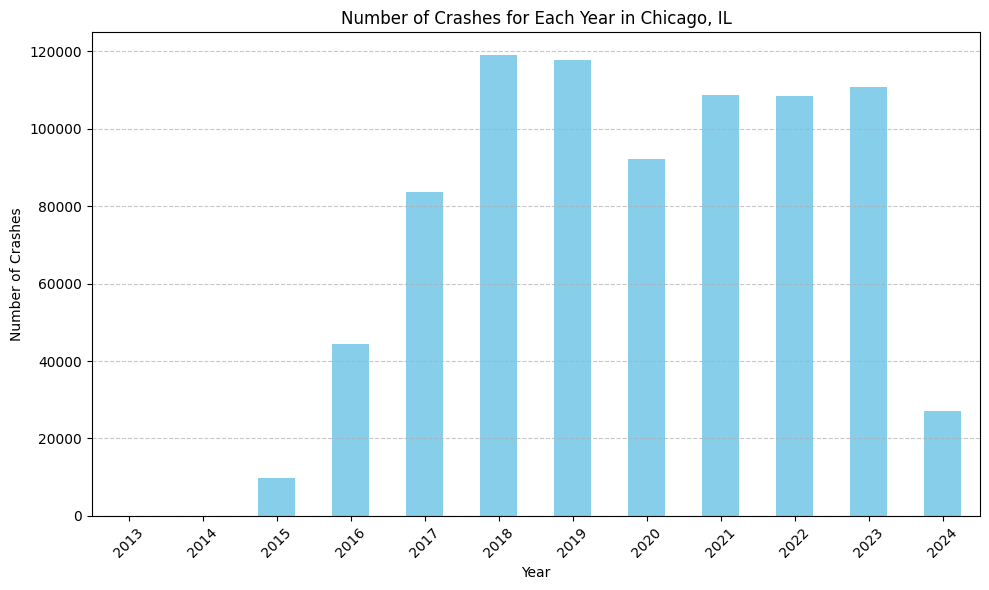

In [94]:


unique_values_by_year = dfv.groupby('YEAR')['CRASH_RECORD_ID'].nunique()

plt.figure(figsize=(10, 6))
unique_values_by_year.plot(kind='bar', color='skyblue')
plt.title('Number of Crashes for Each Year in Chicago, IL')
plt.xlabel('Year')
plt.ylabel('Number of Crashes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


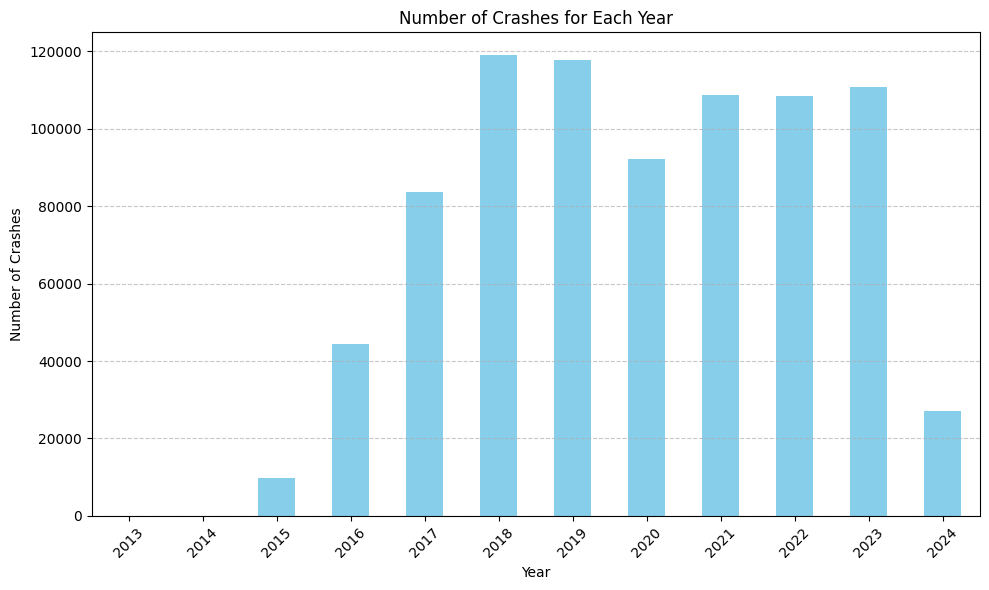

In [95]:
unique_values_by_year = dfv.groupby('YEAR')['CRASH_RECORD_ID'].nunique()

plt.figure(figsize=(10, 6))
unique_values_by_year.plot(kind='bar', color='skyblue')
plt.title('Number of Crashes for Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Crashes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Fatal Crashes 

In [96]:
fatalilities = dfd[dfd["INJURY_CLASSIFICATION"] == 'FATAL']

In [97]:
fatal_crashes = set(fatalilities['CRASH_RECORD_ID'].to_list())

In [98]:
len(fatal_crashes)

907

In [99]:
fatal_dfv =  dfv[dfv['CRASH_RECORD_ID'].isin(fatal_crashes)]

In [100]:
unique_values = fatal_dfv['CRASH_RECORD_ID'].nunique()
print("Number of unique instances:", unique_values)

Number of unique instances: 907


In [101]:
fatal_dfd =  dfd[dfd['CRASH_RECORD_ID'].isin(fatal_crashes)]

In [102]:
fatal_dfd.to_csv("fatal_crashes_people.csv")
fatal_dfv.to_csv("fatal_crashes_vehicles.csv")

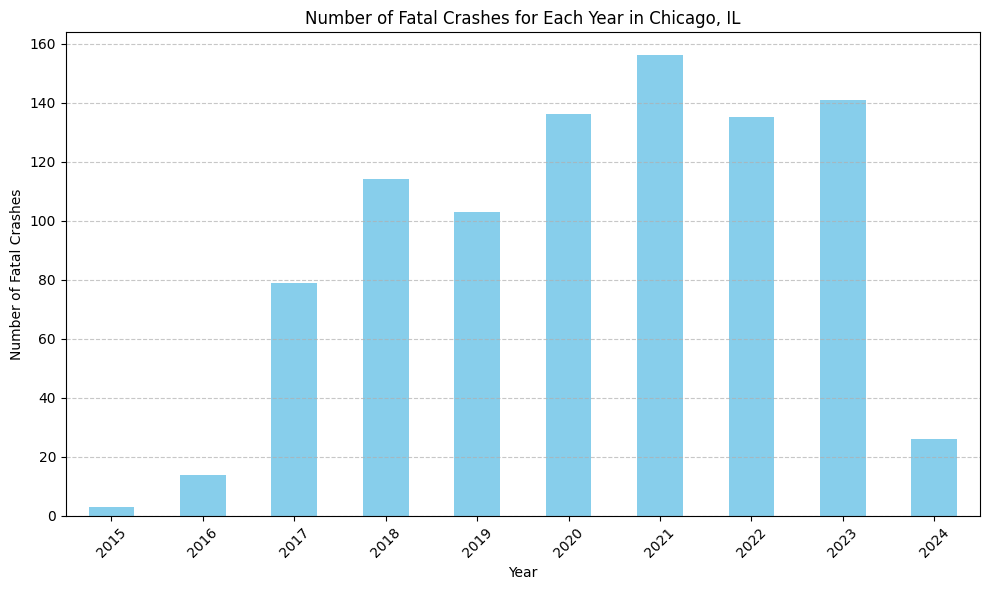

In [103]:
unique_values_by_year = fatal_dfv.groupby('YEAR')['CRASH_RECORD_ID'].nunique()

plt.figure(figsize=(10, 6))
unique_values_by_year.plot(kind='bar', color='skyblue')
plt.title('Number of Fatal Crashes for Each Year in Chicago, IL')
plt.xlabel('Year')
plt.ylabel('Number of Fatal Crashes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

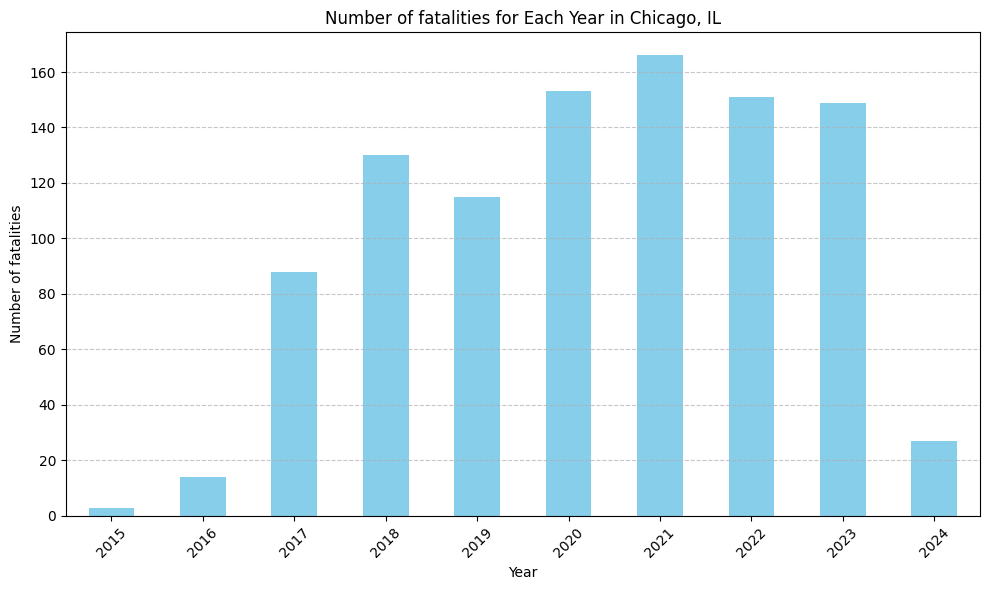

In [104]:

year_counts = fatalilities.groupby('YEAR').size()

plt.figure(figsize=(10, 6))
year_counts.plot(kind='bar', color='skyblue')
plt.title('Number of fatalities for Each Year in Chicago, IL')
plt.xlabel('Year')
plt.ylabel('Number of fatalities')
plt.xticks(rotation=45)  
plt.grid(axis='y', linestyle='--', alpha=0.7)  
plt.tight_layout()
plt.show()


In [105]:
fatal_dfv = fatal_dfv.drop(fatal_dfv.columns[0], axis=1)
fatal_dfd = fatal_dfd.drop(fatal_dfd.columns[0], axis=1)


In [106]:
fatal_dfv.columns #'NUM_PASSENGERS', 'LIC_PLATE_STATE', 'VEHICLE_YEAR', 'VEHICLE_DEFECT', 'VEHICLE_TYPE', 'VEHICLE_USE','MANEUVER','EXCEED_SPEED_LIMIT_I',  

Index(['UNIT_NO', 'UNIT_TYPE', 'NUM_PASSENGERS', 'VEHICLE_ID', 'CMRC_VEH_I',
       'MAKE', 'MODEL', 'LIC_PLATE_STATE', 'VEHICLE_YEAR', 'VEHICLE_DEFECT',
       'VEHICLE_TYPE', 'VEHICLE_USE', 'TRAVEL_DIRECTION', 'MANEUVER',
       'TOWED_I', 'FIRE_I', 'OCCUPANT_CNT', 'EXCEED_SPEED_LIMIT_I', 'TOWED_BY',
       'TOWED_TO', 'AREA_00_I', 'AREA_01_I', 'AREA_02_I', 'AREA_03_I',
       'AREA_04_I', 'AREA_05_I', 'AREA_06_I', 'AREA_07_I', 'AREA_08_I',
       'AREA_09_I', 'AREA_10_I', 'AREA_11_I', 'AREA_12_I', 'AREA_99_I',
       'FIRST_CONTACT_POINT', 'CMV_ID', 'USDOT_NO', 'CCMC_NO', 'ILCC_NO',
       'COMMERCIAL_SRC', 'GVWR', 'CARRIER_NAME', 'CARRIER_STATE',
       'CARRIER_CITY', 'HAZMAT_PLACARDS_I', 'HAZMAT_NAME', 'UN_NO',
       'HAZMAT_PRESENT_I', 'HAZMAT_REPORT_I', 'HAZMAT_REPORT_NO',
       'MCS_REPORT_I', 'MCS_REPORT_NO', 'HAZMAT_VIO_CAUSE_CRASH_I',
       'MCS_VIO_CAUSE_CRASH_I', 'IDOT_PERMIT_NO', 'WIDE_LOAD_I',
       'TRAILER1_WIDTH', 'TRAILER2_WIDTH', 'TRAILER1_LENGTH',
       'TRAI

In [107]:
set(fatal_dfv["CMRC_VEH_I"].to_list())

{'N', 'Y', nan}

In [108]:
fatal_dfv

,UNIT_NO,UNIT_TYPE,NUM_PASSENGERS,VEHICLE_ID,CMRC_VEH_I,MAKE,MODEL,LIC_PLATE_STATE,VEHICLE_YEAR,VEHICLE_DEFECT,...,VEHICLE_CONFIG,CARGO_BODY_TYPE,LOAD_TYPE,HAZMAT_OUT_OF_SERVICE_I,MCS_OUT_OF_SERVICE_I,HAZMAT_CLASS,CRASH_RECORD_ID,YEAR,MONTH,Day of Week
3077,1,DRIVER,NaN,950414.0,N,FORD,F150,IL,2007.0,UNKNOWN,...,NaN,NaN,NaN,NaN,NaN,NaN,518520,2020,December,Wednesday
3078,2,PEDESTRIAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,518520,2020,December,Wednesday
3398,1,DRIVER,3.0,950677.0,NaN,KIA,OPTIMA / K5,IL,2015.0,NONE,...,NaN,NaN,NaN,NaN,NaN,NaN,213272,2020,December,Wednesday
3399,2,DRIVER,NaN,950671.0,NaN,UNKNOWN,OTHER (EXPLAIN IN NARRATIVE),NaN,NaN,UNKNOWN,...,NaN,NaN,NaN,NaN,NaN,NaN,213272,2020,December,Wednesday
4949,1,DRIVER,NaN,952111.0,NaN,FORD,TAURUS,IL,2004.0,UNKNOWN,...,NaN,NaN,NaN,NaN,NaN,NaN,250586,2020,December,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1671775,4,DRIVER,NaN,1705617.0,NaN,CHEVROLET,MALIBU,IN,2016.0,NONE,...,NaN,NaN,NaN,NaN,NaN,NaN,453100,2024,April,Thursday
1673282,1,DRIVER,NaN,1699147.0,NaN,FORD,F250,IL,2020.0,NONE,...,NaN,NaN,NaN,NaN,NaN,NaN,358351,2024,March,Thursday
1673283,2,DISABLED VEHICLE,1.0,1699153.0,NaN,CHEVROLET,EQUINOX,IL,NaN,UNKNOWN,...,NaN,NaN,NaN,NaN,NaN,NaN,358351,2024,March,Thursday
1673284,3,PEDESTRIAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,358351,2024,March,Thursday


### Correlation for Fatal Crashes 